### Generate a Random Walk
Whereas stock returns are often modeled as white noise, stock prices closely follow a random walk. In other words, today's price is yesterday's price plus some random noise.

You will simulate the price of a stock over time that has a starting price of 100 and every day goes up or down by a random amount. Then, plot the simulated stock price. If you hit the "Run Code" code button multiple times, you'll see several realizations.

- Generate 500 random normal "steps" with mean=0 and standard deviation=1 using np.random.normal(), where the argument for the mean is loc and the argument for the standard deviation is scale.
- Simulate stock prices P:
    - Cumulate the random steps using the numpy .cumsum() method
    - Add 100 to P to get a starting stock price of 100.
- Plot the simulated random walk

In [ ]:
# Generate 500 random steps with mean=0 and standard deviation=1
steps = np.random.normal(loc=0, scale=1, size=500)

# Set first element to 0 so that the first price will be the starting stock price
steps[0]=0

# Simulate stock prices, P with a starting price of 100
P = 100 + np.cumsum(steps)

# Plot the simulated stock prices
plt.plot(P)
plt.title("Simulated Random Walk")
plt.show()

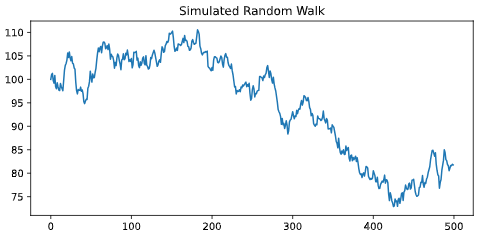

### Get the Drift
In the last exercise, you simulated stock prices that follow a random walk. You will extend this in two ways in this exercise.

You will look at a random walk with a drift. Many time series, like stock prices, are random walks but tend to drift up over time.
In the last exercise, the noise in the random walk was additive: random, normal changes in price were added to the last price. However, when adding noise, you could theoretically get negative prices. Now you will make the noise multiplicative: you will add one to the random, normal changes to get a total return, and multiply that by the last price.

- Generate 500 random normal multiplicative "steps" with mean 0.1% and standard deviation 1% using np.random.normal(), which are now returns, and add one for total return.
- Simulate stock prices P:
    - Cumulate the product of the steps using the numpy .cumprod() method.
    - Multiply the cumulative product of total returns by 100 to get a starting value of 100.
- Plot the simulated random walk with drift.

In [ ]:
# Generate 500 random steps
steps = np.random.normal(loc=0.001, scale=0.01, size=500) + 1

# Set first element to 1
steps[0]=1

# Simulate the stock price, P, by taking the cumulative product
P = 100 * np.cumprod(steps)

# Plot the simulated stock prices
plt.plot(P)
plt.title("Simulated Random Walk with Drift")
plt.show()

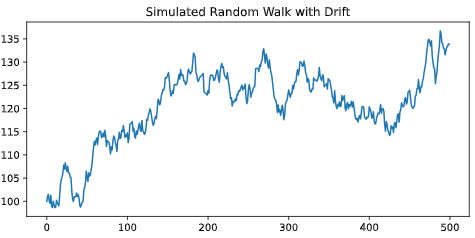

### Are Stock Prices a Random Walk?
Most stock prices follow a random walk (perhaps with a drift). You will look at a time series of Amazon stock prices, pre-loaded in the DataFrame AMZN, and run the 'Augmented Dickey-Fuller Test' from the statsmodels library to show that it does indeed follow a random walk.

With the ADF test, the "null hypothesis" (the hypothesis that we either reject or fail to reject) is that the series follows a random walk. Therefore, a low p-value (say less than 5%) means we can reject the null hypothesis that the series is a random walk.

- Import the adfuller module from statsmodels.
- Run the Augmented Dickey-Fuller test on the series of closing stock prices, which is the column 'Adj Close' in the AMZN DataFrame.
- Print out the entire output, which includes the test statistic, the p-values, and the critical values for tests with 1%, 10%, and 5% levels.
Print out just the p-value of the test (results[0] is the test statistic, and results[1] is the p-value).

In [ ]:
# Import the adfuller module from statsmodels
from statsmodels.tsa.stattools import adfuller

# Run the ADF test on the price series and print out the results
results = adfuller(AMZN['Adj Close'])
print(results)

# Just print out the p-value
print('The p-value of the test on prices is: ' + str(results[1]))

#correct output:
(4.025168525770738, 1.0, 33, 5054, {'1%': -3.4316445438146865, '5%': -2.862112049726916, '10%': -2.5670745025321304}, 30308.64216426981)
    The p-value of the test on prices is: 1.0

### How About Stock Returns?
In the last exercise, you showed that Amazon stock prices, contained in the DataFrame AMZN follow a random walk. In this exercise. you will do the same thing for Amazon returns (percent change in prices) and show that the returns do not follow a random walk.

- Import the adfuller module from statsmodels.
- Create a new DataFrame of AMZN returns by taking the percent change of prices using the method .pct_change().
- Eliminate the NaN in the first row of returns using the .dropna() method on the DataFrame.
- Run the Augmented Dickey-Fuller test on the 'Adj Close' column of AMZN_ret, and print out the p-value in results[1].

In [ ]:
# Import the adfuller module from statsmodels
from statsmodels.tsa.stattools import adfuller

# Create a DataFrame of AMZN returns
AMZN_ret = AMZN.pct_change()

# Eliminate the NaN in the first row of returns
AMZN_ret = AMZN_ret.dropna()

# Run the ADF test on the return series and print out the p-value
results = adfuller(AMZN_ret)
print('The p-value of the test on returns is: ' + str(results[1]))

#correct output:
The p-value of the test on returns is: 2.565589808348563e-22